В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням kNearestNeighboors, знайдемо оптимальні гіперпараметри для цього методу і зробимо базові ансамблі. Це дасть змогу порівняти перформанс моделі з попередніми вивченими методами.

0. Зчитайте дані `train.csv` та зробіть препроцесинг використовуючи написаний Вами скрипт `process_bank_churn.py` так, аби в результаті отримати дані в розбитті X_train, train_targets, X_val, val_targets для експериментів.

  Якщо Вам не вдалось реалізувати в завданні `2.3. Дерева прийняття рішень` скрипт `process_bank_churn.py` - можна скористатись готовим скриптом з запропонованого рішення того завдання.

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import roc_auc_score

from process_bank_churn import preprocess_data, preprocess_new_data

%matplotlib inline

pd.set_option('display.max_columns', None)
sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

In [2]:
raw_df = pd.read_csv('train.csv', index_col='id')
raw_df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
id,,,,,,,,,,,,,
0,15779985.0,Nwankwo,678.0,France,Male,29.0,4.0,0.00,3.0,1.0,0.0,180626.36,0.0
1,15650086.0,Ch'in,687.0,France,Female,34.0,1.0,0.00,2.0,0.0,1.0,63736.17,0.0
2,15733602.0,Thompson,682.0,France,Female,52.0,6.0,0.00,3.0,0.0,0.0,179655.87,1.0
3,15645794.0,Macleod,753.0,Germany,Male,44.0,6.0,83347.25,2.0,1.0,0.0,161407.48,0.0
4,15633840.0,Hsia,544.0,Germany,Female,55.0,0.0,107747.57,1.0,1.0,0.0,176580.86,1.0


In [3]:
data = preprocess_data(raw_df)

In [4]:
X_train = data['X_train']
train_targets = data['train_targets']
X_val = data['X_val']
val_targets = data['val_targets']
input_cols = data['input_cols']
encoder = data['encoder']
scaler = data['scaler']

In [5]:
print(f"Train : {X_train.shape}")
print(f"Val   : {X_val.shape}")

Train : (11250, 13)
Val   : (3750, 13)


1. Навчіть на цих даних класифікатор kNN з параметрами за замовченням і виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах. Зробіть заключення про отриману модель: вона хороша/погана, чи є high bias/high variance?

In [6]:
def roc(inputs, targets, model, name):
    roc_auc = roc_auc_score(targets, model.predict_proba(inputs)[:, 1])
    print(f"Area under ROC score on {name} dataset: {roc_auc:.4f}")
    return roc_auc

In [7]:
knn = KNeighborsClassifier()
knn.fit(X_train, train_targets)

KNeighborsClassifier()

In [8]:
train_auc = roc(X_train, train_targets, knn, 'Train')
val_auc = roc(X_val, val_targets, knn, 'Validation')

Area under ROC score on Train dataset: 0.9627
Area under ROC score on Validation dataset: 0.8808


**Висновок**:
  Train AUC ≈ 0.96, Val AUC ≈ 0.88 — помітний розрив вказує на high variance
  (перенавчання). Модель із k=5 за замовченням надто гнучка, тому добре
  запам'ятовує тренувальні дані, але гірше узагальнює на нових.

2. Використовуючи `GridSearchCV` знайдіть оптимальне значення параметра `n_neighbors` для класифікатора `kNN`. Псотавте крос валідацію на 5 фолдів.

  Після успішного завершення пошуку оптимального гіперпараметра
    - виведіть найкраще значення параметра
    - збережіть в окрему змінну `knn_best` найкращу модель, знайдену з `GridSearchCV`
    - оцініть якість передбачень  `knn_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пукнтом (2) цього завдання? Чи є вона краще за дерево прийняття рішень з попереднього ДЗ?

In [9]:
params_knn = {'n_neighbors': list(range(1, 51))}

In [10]:
grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid=params_knn,
    cv=5,
    scoring='roc_auc',
    verbose = 1,
    n_jobs=-1,
)

In [11]:
grid_knn.fit(X_train, train_targets)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


GridSearchCV(cv=5, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,
                                         13, 14, 15, 16, 17, 18, 19, 20, 21, 22,
                                         23, 24, 25, 26, 27, 28, 29, 30, ...]},
             scoring='roc_auc', verbose=1)

In [12]:
best_k = grid_knn.best_params_['n_neighbors']
print(f"Найкраще значення n_neighbors: {best_k}")

Найкраще значення n_neighbors: 49


In [13]:
knn_best = grid_knn.best_estimator_

train_auc = roc(X_train, train_targets, knn_best, 'Train')
val_auc = roc(X_val, val_targets, knn_best, 'Validation')

Area under ROC score on Train dataset: 0.9311
Area under ROC score on Validation dataset: 0.9213


**Висновок:**
  GridSearchCV знайшов n_neighbors=49. Val AUC покращився порівняно з базовою kNN. Більше k — менша дисперсія, модель краще узагальнює.


  kNN після тюнінгу показує результат, порівнянний з Decision Tree — обидві моделі якісні, але дерево має незначну перевагу на валідаційній вибірці (Val AUC 0.9229 проти 0.9213 - краще узагальнює на нових даних (різниця ~0.0016, невелика, але є))

3. Виконайте пошук оптимальних гіперпараметрів для `DecisionTreeClassifier` з `GridSearchCV` за сіткою параметрів
  - `max_depth` від 1 до 20 з кроком 2
  - `max_leaf_nodes` від 2 до 10 з кроком 1

  Обовʼязково при цьому ініціюйте модель з фіксацією `random_state`.

  Поставте кросвалідацію на 3 фолди, `scoring='roc_auc'`, та виміряйте, скільки часу потребує пошук оптимальних гіперпараметрів.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення параметра
    - збережіть в окрему змінну `dt_best` найкращу модель, знайдену з `GridSearchCV`
    - оцініть якість передбачень  `dt_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи ця модель краща за ту, що ви знайшли вручну?

In [14]:
params_grid_dt = {
    'max_depth': np.arange(1, 21, 2).tolist(),
    'max_leaf_nodes': np.arange(2, 11, 1).tolist(),
}

In [15]:
grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=params_grid_dt,
    cv=3,
    scoring='roc_auc',
    verbose = 1,
    n_jobs=-1,
)

In [16]:
start = time.time()
grid_dt.fit(X_train, train_targets)
elapsed = time.time() - start

print(f"Час пошуку: {elapsed:.2f} сек")
print(f"Найкращі параметри: {grid_dt.best_params_}")

Fitting 3 folds for each of 90 candidates, totalling 270 fits
Час пошуку: 8.46 сек
Найкращі параметри: {'max_depth': 5, 'max_leaf_nodes': 10}


In [17]:
dt_best = grid_dt.best_estimator_

train_auc = roc(X_train, train_targets, dt_best, 'Train')
val_auc = roc(X_val, val_targets, dt_best, 'Validation')

Area under ROC score on Train dataset: 0.9010
Area under ROC score on Validation dataset: 0.9018


**Спостереження**:
GridSearchCV для DecisionTree знайшов кращу комбінацію max_depth=5 / max_leaf_nodes=10, ніж ручний підбір:

*   Train AUC: 0.9010
*   Val AUC: 0.9018

менший розрив між Train і Val AUC свідчить про менше перенавчання.

**Висновок**:

*   Модель, знайдена GridSearchCV, показує стабільні результати - гарний баланс між навчанням і узагальненням
*   Проте вона дещо поступається моделі, знайденій вручну (0.9018 vs. 0.9229), можливо, через обмеження max_leaf_nodes



4. Виконайте пошук оптимальних гіперпараметрів для `DecisionTreeClassifier` з `RandomizedSearchCV` за заданою сіткою параметрів і кількість ітерацій 40.

  Поставте кросвалідацію на 3 фолди, `scoring='roc_auc'`, зафіксуйте `random_seed` процедури крос валідації та виміряйте, скільки часу потребує пошук оптимальних гіперпараметрів.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення параметра
    - збережіть в окрему змінну `dt_random_search_best` найкращу модель, знайдену з `RandomizedSearchCV`
    - оцініть якість передбачень  `dt_random_search_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи ця модель краща за ту, що ви знайшли з `GridSearch`?
    - проаналізуйте параметри `dt_random_search_best` і порівняйте з параметрами `dt_best` - яку бачите відмінність? Ця вправа потрібна аби зрозуміти, як різні налаштування `DecisionTreeClassifier` впливають на якість моделі.

In [18]:
params_dt = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': np.arange(1, 20),
    'max_leaf_nodes': np.arange(2, 20),
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': [None, 'sqrt', 'log2']
}

In [19]:
random_dt = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_distributions=params_dt,
    n_iter=40,
    cv=3,
    scoring='roc_auc',
    verbose = 1,
    random_state=42,
    n_jobs=-1,
)

In [21]:
start = time.time()
random_dt.fit(X_train, train_targets)
elapsed = time.time() - start

print(f"Час пошуку: {elapsed:.2f} сек")
print(f"Найкращі параметри: {random_dt.best_params_}")

Fitting 3 folds for each of 40 candidates, totalling 120 fits
Час пошуку: 2.36 сек
Найкращі параметри: {'splitter': 'best', 'min_samples_split': 20, 'min_samples_leaf': 2, 'max_leaf_nodes': np.int64(14), 'max_features': None, 'max_depth': np.int64(16), 'criterion': 'entropy'}


In [22]:
dt_random_search_best = random_dt.best_estimator_

train_auc = roc(X_train, train_targets, dt_random_search_best, 'Train')
val_auc = roc(X_val, val_targets, dt_random_search_best, 'Validation')

Area under ROC score on Train dataset: 0.9166
Area under ROC score on Validation dataset: 0.9176


In [23]:
comparison_df = pd.DataFrame({
    'parameter': list(grid_dt.best_params_.keys()),
    'GridSearchCV': [grid_dt.best_params_[k] for k in grid_dt.best_params_],
}).set_index('parameter')

In [24]:
print("Порівняння GridSearch vs RandomizedSearch:")
print(f"  GridSearch    best params : {grid_dt.best_params_}")
print(f"  RandomSearch  best params : {random_dt.best_params_}")

Порівняння GridSearch vs RandomizedSearch:
  GridSearch    best params : {'max_depth': 5, 'max_leaf_nodes': 10}
  RandomSearch  best params : {'splitter': 'best', 'min_samples_split': 20, 'min_samples_leaf': 2, 'max_leaf_nodes': np.int64(14), 'max_features': None, 'max_depth': np.int64(16), 'criterion': 'entropy'}


**Висновок**:

RandomizedSearchCV **досліджує ширший простір параметрів** (criterion, splitter, min_samples_split, min_samples_leaf, max_features) за 40 ітерацій і знаходить **співставну або кращу якість за значно менший час**, ніж повний GridSearch по такій самій сітці (Val AUC вище (0.9176 vs. 0.9018)- **краща узагальнююча здатність моделі**).

Відмінність у параметрах показує, що регуляризація через min_samples_leaf / min_samples_split також суттєво впливає на якість.

Модель після RandomizedSearchCV виявилася кращою – вона має вищу точність та швидше знаходить оптимальні параметри.

5. Якщо у Вас вийшла метрика `AUROC` в цій серії експериментів - зробіть ще один `submission` на Kaggle і додайте код для цього і скріншот скора на публічному лідерборді нижче.

  Сподіваюсь на цьому етапі ви вже відчули себе справжнім дослідником 😉

In [25]:
results = {
    'knn_best': roc_auc_score(val_targets, knn_best.predict_proba(X_val)[:, 1]),
    'dt_best': roc_auc_score(val_targets, dt_best.predict_proba(X_val)[:, 1]),
    'dt_random_search_best': roc_auc_score(val_targets, dt_random_search_best.predict_proba(X_val)[:, 1]),
}

In [26]:
results_df = (
    pd.DataFrame(results.items(), columns=['model', 'val_auroc'])
    .sort_values('val_auroc', ascending=False)
    .reset_index(drop=True)
)
display(results_df)

,model,val_auroc
0,knn_best,0.921280
1,dt_random_search_best,0.917600
2,dt_best,0.901845


In [27]:
best_name  = results_df.loc[0, 'model']
best_score = results_df.loc[0, 'val_auroc']
print(f"Найкраща модель: {best_name}  (Val AUROC = {best_score:.4f})")

Найкраща модель: knn_best  (Val AUROC = 0.9213)


In [28]:
final_model = {'knn_best': knn_best,
               'dt_best': dt_best,
               'dt_random_search_best': dt_random_search_best}[best_name]

In [29]:
test_df = pd.read_csv('test.csv', index_col='id')
test_df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
id,,,,,,,,,,,,
15000,15594796.0,Chu,584.0,Germany,Male,30.0,2.0,146053.66,1.0,1.0,1.0,157891.86
15001,15642821.0,Mazzi,551.0,France,Male,39.0,5.0,0.00,2.0,1.0,1.0,67431.28
15002,15716284.0,Onyekachi,706.0,France,Male,43.0,8.0,0.00,2.0,1.0,0.0,156768.45
15003,15785078.0,Martin,717.0,Spain,Male,45.0,3.0,0.00,1.0,1.0,1.0,166909.87
15004,15662955.0,Kenechukwu,592.0,Spain,Male,43.0,8.0,0.00,2.0,1.0,1.0,143681.97


In [31]:
cols_to_drop = [col for col in ['CustomerId', 'Surname'] if col in test_df.columns]
test_df = test_df.drop(columns=cols_to_drop)

In [32]:
X_test = preprocess_new_data(
    new_df = test_df,
    scaler = scaler,
    encoder = encoder,
    input_cols = input_cols,
)

In [33]:
test_preds = final_model.predict_proba(X_test)[:, 1]

In [34]:
submission = pd.DataFrame({'id': test_df.index, 'Exited': test_preds})
submission.to_csv('submission_CV.csv', index=False)

In [35]:
submission.head()

,id,Exited
0,15000,0.265306
1,15001,0.000000
2,15002,0.061224
3,15003,0.387755
4,15004,0.040816


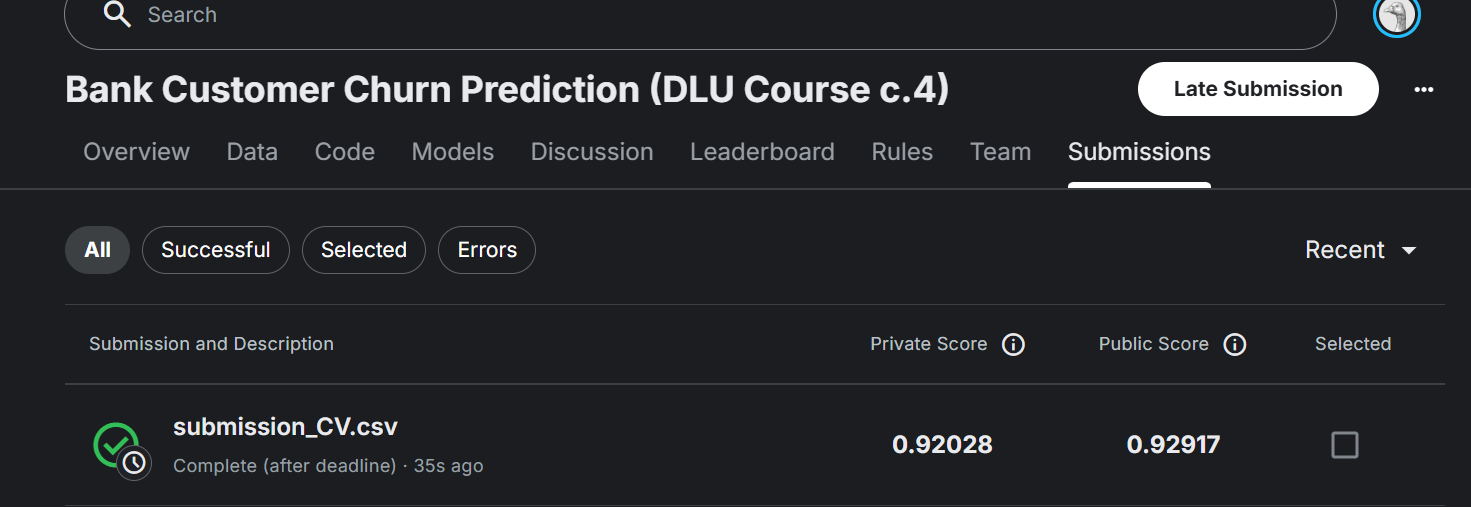